# Real-World Dataset Analysis Project
## Titanic Passenger Dataset
Complete workflow: exploration, cleaning, EDA, visualization, interpretation, and reporting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Dataset Exploration

In [2]:
print('Shape:', df.shape)
print(df.dtypes)
print(df.isnull().sum())
print('Duplicates:', df.duplicated().sum())

Shape: (891, 15)
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
Duplicates: 107


## Cleaning and Preprocessing

In [3]:
data = df.drop_duplicates().copy()
data['age'] = data['age'].fillna(data['age'].median())
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])
data['embark_town'] = data['embark_town'].fillna(data['embark_town'].mode()[0])
data['deck'] = data['deck'].astype('object').fillna('Unknown')
data.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

## Exploratory Data Analysis

In [4]:
print(data[['age','fare','sibsp','parch']].describe())
print('Overall survival rate:', data['survived'].mean())
print(data.groupby('sex', observed=False)['survived'].mean())
print(data.groupby('class', observed=False)['survived'].mean())

              age        fare       sibsp       parch
count  784.000000  784.000000  784.000000  784.000000
mean    29.650408   34.711740    0.522959    0.415816
std     13.734925   52.160151    0.986231    0.836922
min      0.420000    0.000000    0.000000    0.000000
25%     22.000000    8.050000    0.000000    0.000000
50%     28.250000   15.900000    0.000000    0.000000
75%     36.000000   34.109350    1.000000    1.000000
max     80.000000  512.329200    8.000000    6.000000
Overall survival rate: 0.4119897959183674
sex
female    0.740614
male      0.215886
Name: survived, dtype: float64
class
First     0.630841
Second    0.509091
Third     0.256790
Name: survived, dtype: float64


          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.332658 -0.079184 -0.036589  0.070307  0.246769
pclass   -0.332658  1.000000 -0.342986  0.088014  0.040296 -0.549216
age      -0.079184 -0.342986  1.000000 -0.279431 -0.183777  0.091315
sibsp    -0.036589  0.088014 -0.279431  1.000000  0.381433  0.135147
parch     0.070307  0.040296 -0.183777  0.381433  1.000000  0.191942
fare      0.246769 -0.549216  0.091315  0.135147  0.191942  1.000000


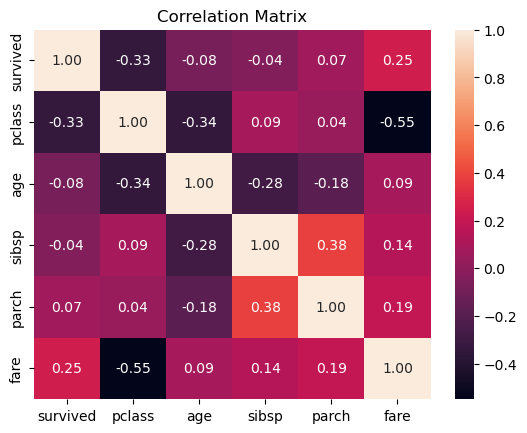

In [5]:
corr = data.select_dtypes(include=np.number).corr()
print(corr)
sns.heatmap(corr, annot=True, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Visualizations

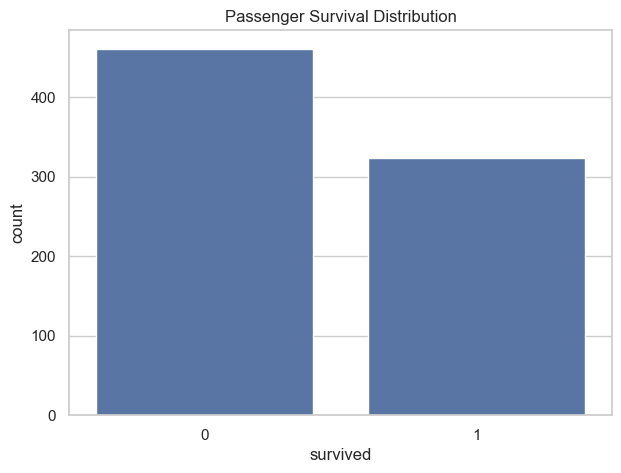

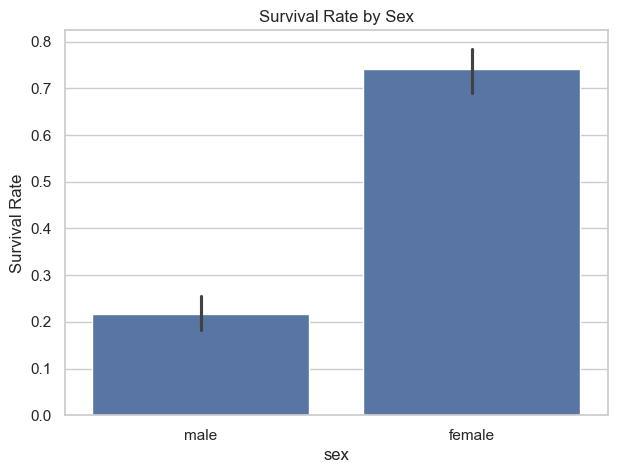

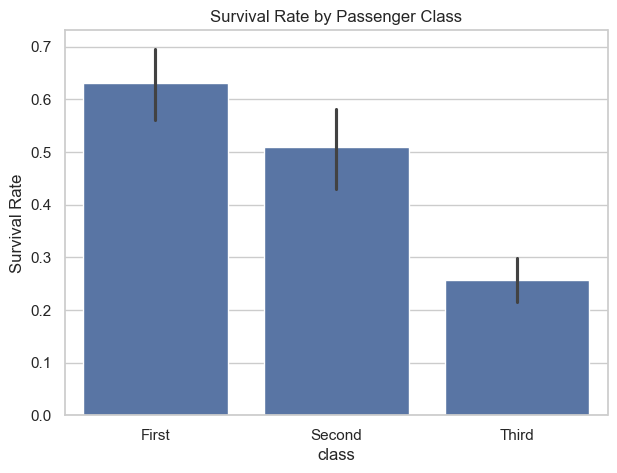

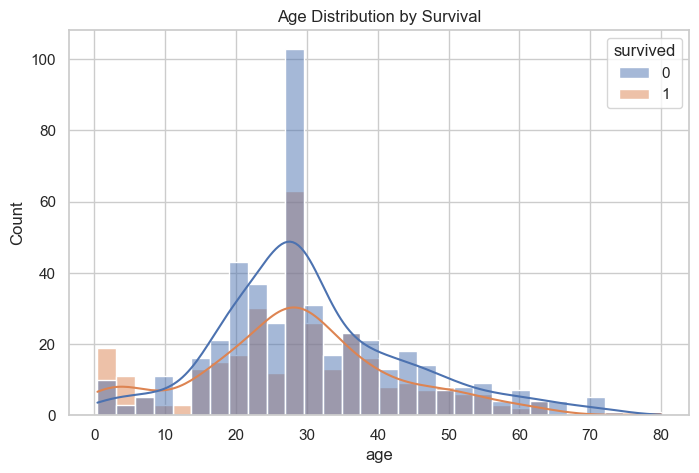

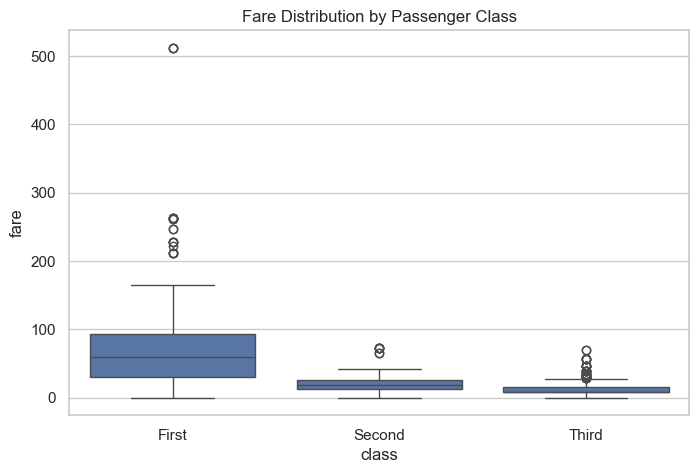

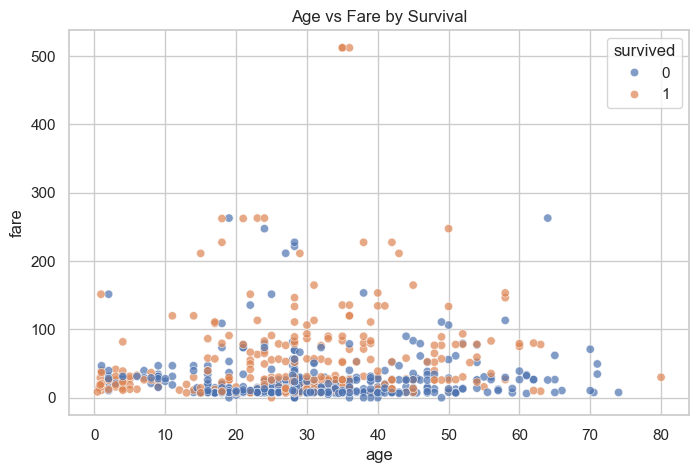

In [6]:
sns.set_theme(style='whitegrid')
figures = []
plt.figure(figsize=(7,5)); sns.countplot(data=data, x='survived'); plt.title('Passenger Survival Distribution'); plt.show()
plt.figure(figsize=(7,5)); sns.barplot(data=data, x='sex', y='survived'); plt.title('Survival Rate by Sex'); plt.ylabel('Survival Rate'); plt.show()
plt.figure(figsize=(7,5)); sns.barplot(data=data, x='class', y='survived', order=['First','Second','Third']); plt.title('Survival Rate by Passenger Class'); plt.ylabel('Survival Rate'); plt.show()
plt.figure(figsize=(8,5)); sns.histplot(data=data, x='age', hue='survived', bins=30, kde=True); plt.title('Age Distribution by Survival'); plt.show()
plt.figure(figsize=(8,5)); sns.boxplot(data=data, x='class', y='fare', order=['First','Second','Third']); plt.title('Fare Distribution by Passenger Class'); plt.show()
plt.figure(figsize=(8,5)); sns.scatterplot(data=data, x='age', y='fare', hue='survived', alpha=.7); plt.title('Age vs Fare by Survival'); plt.show()

## Key Findings and Conclusion
Survival outcomes differ across passenger groups, particularly by sex and passenger class. Age and fare distributions also vary across groups. These are associations in the dataset, not proof of causation. The cleaned dataset is exported for further analysis.

In [8]:
data.to_csv('titanic_cleaned.csv', index=False)
print('Cleaned dataset saved.')

Cleaned dataset saved.
